In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rodsaldanha/arketing-campaign")

print("Path to dataset files:", path)

Path to dataset files: /Users/sarahivillegas/.cache/kagglehub/datasets/rodsaldanha/arketing-campaign/versions/8


In [2]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt

path_filename = "marketing_campaign.csv"
path_file =  os.path.join(path, path_filename)

df = pd.read_csv(path_file, sep=';')

df.sample(5)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
1349,1745,1962,PhD,Divorced,85696.0,0,0,2013-05-03,88,714,...,1,0,0,0,0,0,0,3,11,1
1920,2546,1977,2n Cycle,Single,31878.0,0,1,2014-06-22,7,23,...,3,0,0,0,0,0,0,3,11,0
1951,2162,1976,Graduation,Married,56939.0,0,1,2013-09-18,19,256,...,3,0,0,0,0,0,0,3,11,0
2023,7861,1952,Master,Married,77027.0,0,1,2014-02-05,23,820,...,4,0,0,0,0,0,0,3,11,0
2116,87,1981,2n Cycle,Married,27733.0,1,0,2013-08-26,16,0,...,7,0,0,0,0,0,0,3,11,0


In [3]:
df.drop('Z_Revenue',axis=1,inplace=True)
df.drop('Z_CostContact',axis=1,inplace=True)

In [4]:
df.drop('ID',axis=1,inplace=True)

In [5]:
df.sample(4)

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
1397,1972,Graduation,Divorced,26759.0,1,0,2014-02-07,65,25,3,...,1,3,6,0,0,0,0,0,0,0
2082,1960,Graduation,Married,51651.0,0,1,2012-11-07,32,293,6,...,2,5,8,0,0,0,0,0,0,0
641,1948,PhD,Together,76140.0,0,0,2014-05-13,57,586,66,...,9,6,2,0,0,0,0,0,0,0
300,1958,Graduation,Divorced,35246.0,1,1,2014-04-16,53,36,0,...,1,3,5,0,0,0,0,0,0,0


In [6]:
print('Existen ',df.isnull().sum().sum(),'valores no existentes')

Existen  24 valores no existentes


In [7]:
missing_values_count = df.isnull().sum()
print('Columnas que tienen valores nulos')
print('---------------------------------')
missing_values_count[:10]

Columnas que tienen valores nulos
---------------------------------


Year_Birth         0
Education          0
Marital_Status     0
Income            24
Kidhome            0
Teenhome           0
Dt_Customer        0
Recency            0
MntWines           0
MntFruits          0
dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year_Birth           2240 non-null   int64  
 1   Education            2240 non-null   object 
 2   Marital_Status       2240 non-null   object 
 3   Income               2216 non-null   float64
 4   Kidhome              2240 non-null   int64  
 5   Teenhome             2240 non-null   int64  
 6   Dt_Customer          2240 non-null   object 
 7   Recency              2240 non-null   int64  
 8   MntWines             2240 non-null   int64  
 9   MntFruits            2240 non-null   int64  
 10  MntMeatProducts      2240 non-null   int64  
 11  MntFishProducts      2240 non-null   int64  
 12  MntSweetProducts     2240 non-null   int64  
 13  MntGoldProds         2240 non-null   int64  
 14  NumDealsPurchases    2240 non-null   int64  
 15  NumWebPurchases      2240 non-null   i

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year_Birth,2240.0,1968.805804,11.984069,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.251354,25173.076661,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2240.0,0.444196,0.538398,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.506250,0.544538,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.302232,39.773434,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.950000,225.715373,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.525446,54.628979,0.0,3.00,12.0,50.00,259.0
MntSweetProducts,2240.0,27.062946,41.280498,0.0,1.00,8.0,33.00,263.0


In [10]:
df.shape

(2240, 26)

In [11]:
df.nunique().sort_values()

Response                  2
AcceptedCmp2              2
AcceptedCmp1              2
AcceptedCmp5              2
AcceptedCmp4              2
AcceptedCmp3              2
Complain                  2
Kidhome                   3
Teenhome                  3
Education                 5
Marital_Status            8
NumStorePurchases        14
NumCatalogPurchases      14
NumDealsPurchases        15
NumWebPurchases          15
NumWebVisitsMonth        16
Year_Birth               59
Recency                 100
MntFruits               158
MntSweetProducts        177
MntFishProducts         182
MntGoldProds            213
MntMeatProducts         558
Dt_Customer             663
MntWines                776
Income                 1974
dtype: int64

In [12]:
print('Media: ',df['Income'].mean())
print('Median: ',df['Income'].median())

Media:  52247.25135379061
Median:  51381.5


In [13]:
df.mode(axis='rows',numeric_only=True).T

,0
Year_Birth,1976.0
Income,7500.0
Kidhome,0.0
Teenhome,0.0
Recency,56.0
MntWines,2.0
MntFruits,0.0
MntMeatProducts,7.0
MntFishProducts,0.0
MntSweetProducts,0.0


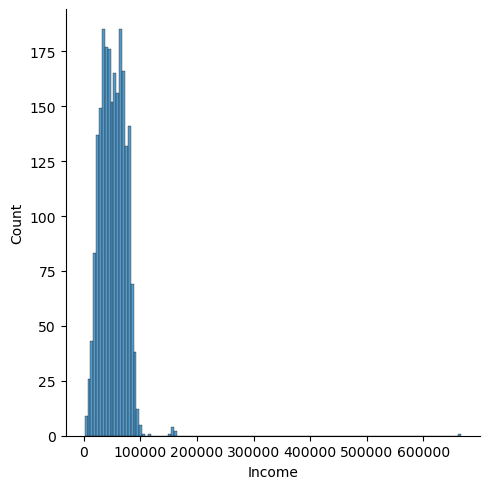

In [14]:
sns.displot(data=df,x='Income')

In [15]:
avg_mean = df['Income'].mean()

df = df.replace(np.nan, avg_mean)

In [16]:
print('Existen ',df.isnull().sum().sum(),'valores no existentes')

Existen  0 valores no existentes


# Análisis univariado

In [17]:
df.dtypes

Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Response                 int64
dtype: object

In [18]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year_Birth,2240.0,1968.805804,11.984069,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2240.0,52247.251354,25037.797168,1730.0,35538.75,51741.5,68289.75,666666.0
Kidhome,2240.0,0.444196,0.538398,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.506250,0.544538,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.302232,39.773434,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.950000,225.715373,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.525446,54.628979,0.0,3.00,12.0,50.00,259.0
MntSweetProducts,2240.0,27.062946,41.280498,0.0,1.00,8.0,33.00,263.0


In [19]:
missing_values_count = df.isnull().sum()
print('Columnas que tienen valores nulos')
print('---------------------------------')
print(df.columns)
print(len(df.columns),'columnas')

cols_num = ['Year_Birth', 'Income', 'Kidhome',
       'Teenhome', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Response']

Columnas que tienen valores nulos
---------------------------------
Index(['Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Response'],
      dtype='object')
26 columnas


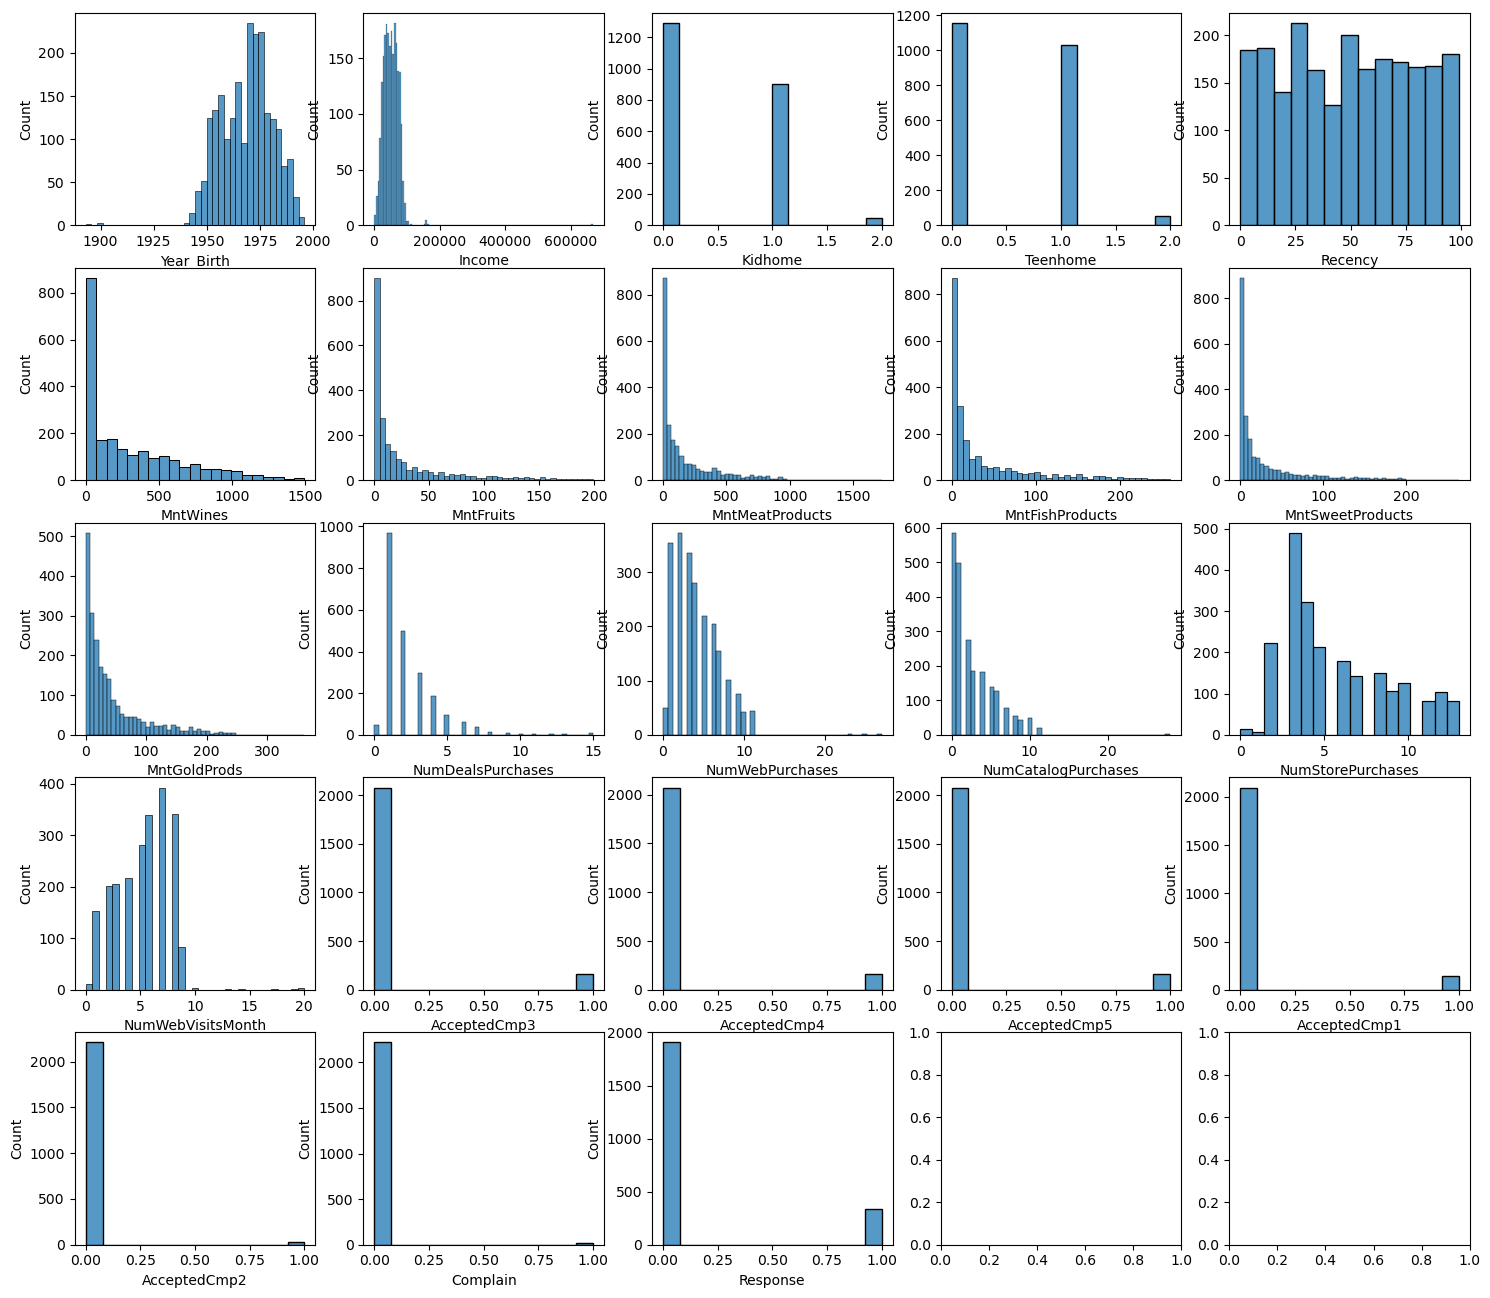

In [20]:
fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(18,16))
for i, column in enumerate(cols_num):
    sns.histplot(df[column],ax=axes[i//5,i%5],kde=False)

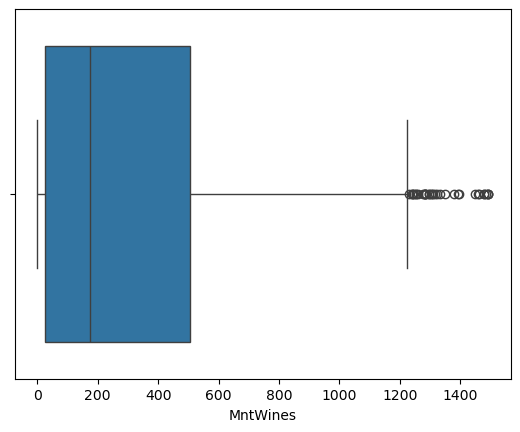

In [21]:
import seaborn as sns
ax = sns.boxplot(x=df['MntWines'])

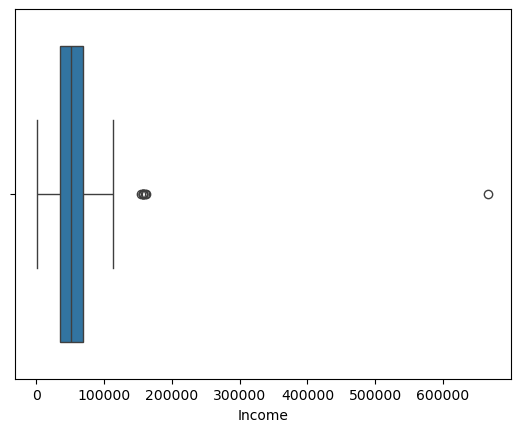

In [22]:
import seaborn as sns
ax = sns.boxplot(x=df['Income'])

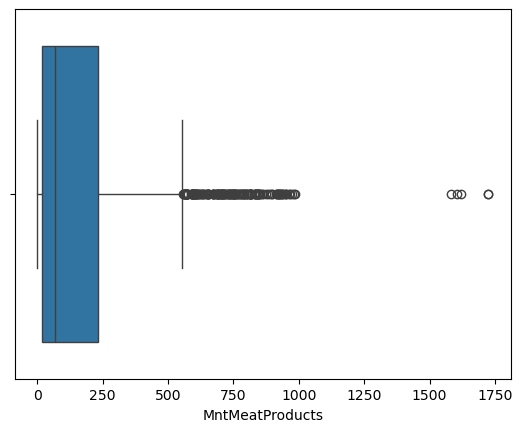

In [23]:
import seaborn as sns
ax = sns.boxplot(x=df['MntMeatProducts'])

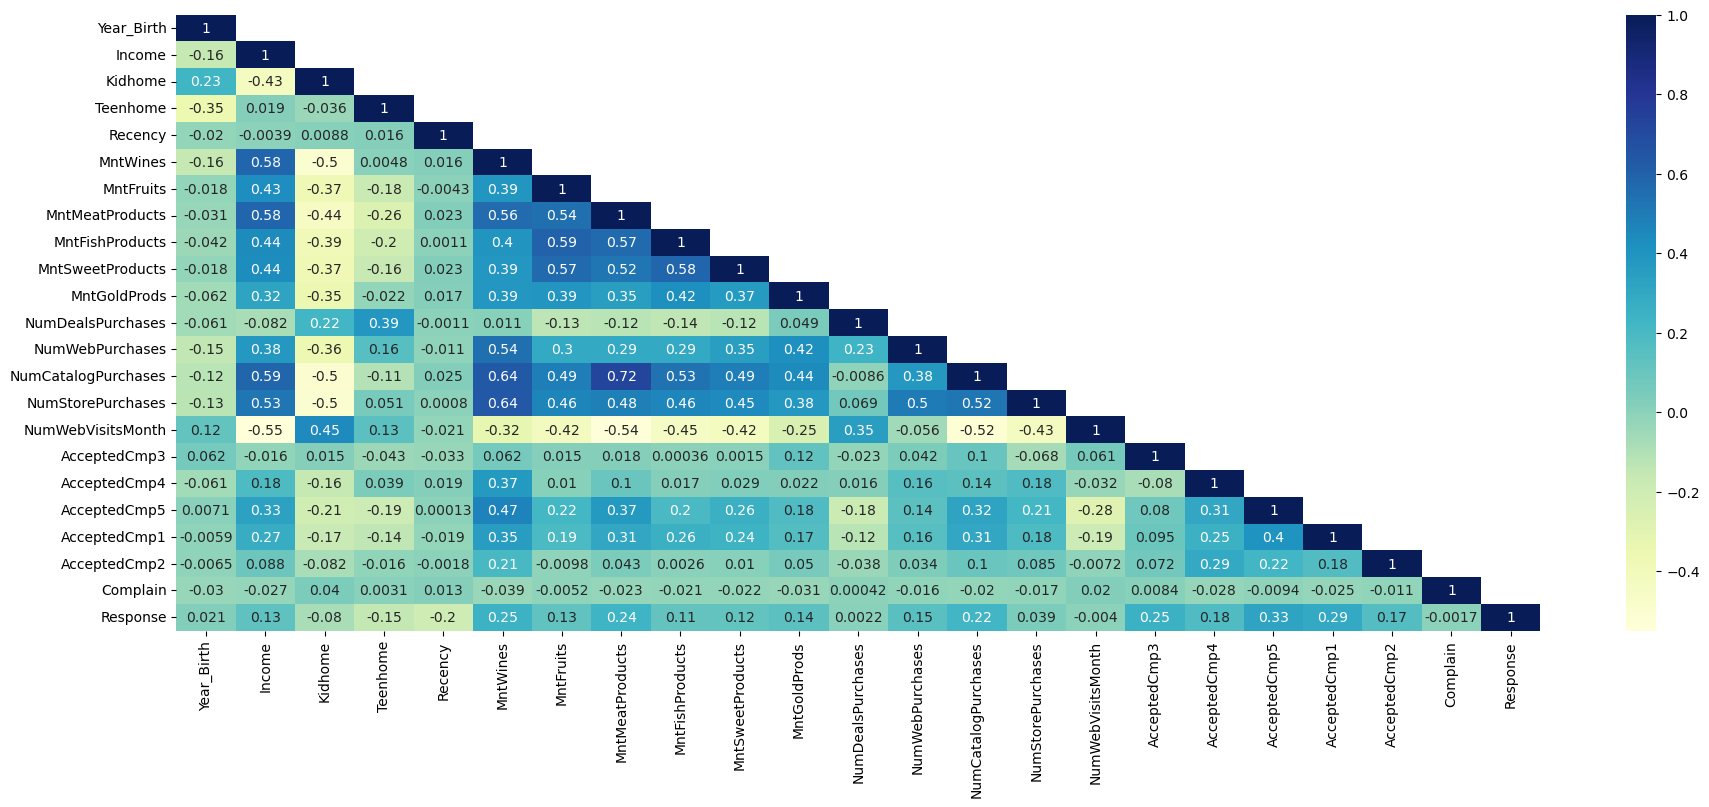

In [24]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(22,8))
corr_df = corr = df.corr(numeric_only=True,method='pearson')
df_lt = corr_df.where(np.tril(np.ones(corr_df.shape)).astype(bool))
hmap = sns.heatmap(df_lt, cmap='YlGnBu',annot=True)

In [25]:
df.corr( numeric_only=True).style.background_gradient(cmap = 'Blues').set_properties(**{'front_size':'10px'})

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
Year_Birth,1.000000,-0.160942,0.230176,-0.352111,-0.019871,-0.157773,-0.017917,-0.030872,-0.041625,-0.018133,-0.061818,-0.060846,-0.145040,-0.121275,-0.128272,0.121139,0.061774,-0.060510,0.007123,-0.005930,-0.006539,-0.030128,0.021325
Income,-0.160942,1.000000,-0.425176,0.019018,-0.003946,0.576789,0.428747,0.577802,0.437497,0.436162,0.321978,-0.082290,0.380550,0.586725,0.526489,-0.549824,-0.016168,0.182791,0.334850,0.274921,0.087538,-0.027223,0.132756
Kidhome,0.230176,-0.425176,1.000000,-0.036133,0.008827,-0.496297,-0.372581,-0.437129,-0.387644,-0.370673,-0.349595,0.221798,-0.361647,-0.502237,-0.499683,0.447846,0.014674,-0.161600,-0.205634,-0.172339,-0.081716,0.040207,-0.080008
Teenhome,-0.352111,0.019018,-0.036133,1.000000,0.016198,0.004846,-0.176764,-0.261160,-0.204187,-0.162475,-0.021725,0.387741,0.155500,-0.110769,0.050695,0.134884,-0.042677,0.038886,-0.191050,-0.140090,-0.015605,0.003138,-0.154446
Recency,-0.019871,-0.003946,0.008827,0.016198,1.000000,0.016064,-0.004306,0.023056,0.001079,0.022670,0.016693,-0.001098,-0.010726,0.025110,0.000799,-0.021445,-0.032991,0.018826,0.000129,-0.019283,-0.001781,0.013231,-0.198437
MntWines,-0.157773,0.576789,-0.496297,0.004846,0.016064,1.000000,0.389637,0.562667,0.399753,0.386581,0.387516,0.010940,0.542265,0.635226,0.642100,-0.320653,0.062202,0.373286,0.472613,0.354133,0.205907,-0.039007,0.247254
MntFruits,-0.017917,0.428747,-0.372581,-0.176764,-0.004306,0.389637,1.000000,0.543105,0.594804,0.567164,0.392995,-0.132114,0.296735,0.487917,0.461758,-0.418383,0.014727,0.010152,0.215833,0.194748,-0.009773,-0.005166,0.125289
MntMeatProducts,-0.030872,0.577802,-0.437129,-0.261160,0.023056,0.562667,0.543105,1.000000,0.568402,0.523846,0.350609,-0.122415,0.293761,0.723827,0.479659,-0.539470,0.018272,0.102912,0.373769,0.309761,0.043033,-0.023483,0.236335
MntFishProducts,-0.041625,0.437497,-0.387644,-0.204187,0.001079,0.399753,0.594804,0.568402,1.000000,0.579870,0.422875,-0.139361,0.293681,0.534478,0.459855,-0.446003,0.000357,0.016843,0.199578,0.260762,0.002577,-0.020953,0.111331
MntSweetProducts,-0.018133,0.436162,-0.370673,-0.162475,0.022670,0.386581,0.567164,0.523846,0.579870,1.000000,0.369724,-0.120100,0.348544,0.490924,0.448756,-0.423294,0.001530,0.028641,0.259590,0.241818,0.009985,-0.022485,0.117372


# Analisis bivariado

In [26]:
df.groupby(['Marital_Status']).mean(numeric_only=True).T

Marital_Status,Absurd,Alone,Divorced,Married,Single,Together,Widow,YOLO
Year_Birth,1975.0,1973.000000,1966.275862,1969.579861,1971.489583,1967.746552,1958.558442,1973.0
Income,72365.5,43789.000000,52834.228448,51729.210370,51018.823463,53233.485792,56426.561706,48432.0
Kidhome,0.0,1.000000,0.413793,0.456019,0.464583,0.450000,0.233766,0.0
Teenhome,0.0,0.666667,0.590517,0.511574,0.406250,0.529310,0.636364,1.0
Recency,53.0,30.333333,49.487069,48.277778,49.506250,50.106897,49.142857,3.0
MntWines,355.5,184.666667,324.844828,299.480324,288.331250,306.825862,369.272727,322.0
MntFruits,84.5,4.000000,27.426724,25.734954,26.835417,25.350000,33.090909,3.0
MntMeatProducts,312.5,26.333333,150.206897,160.681713,182.108333,168.103448,189.285714,50.0
MntFishProducts,205.5,7.666667,35.043103,35.380787,38.216667,38.991379,51.389610,4.0
MntSweetProducts,30.5,7.000000,26.818966,26.701389,27.262500,26.122414,39.012987,3.0


In [27]:
df.groupby(['Response']).median(numeric_only=True).T

Response,0,1
Year_Birth,1970.0,1971.0
Income,50567.0,64044.0
Kidhome,0.0,0.0
Teenhome,1.0,0.0
Recency,52.0,30.0
MntWines,152.0,448.0
MntFruits,7.0,21.0
MntMeatProducts,56.0,174.5
MntFishProducts,11.0,25.0
MntSweetProducts,7.0,20.0


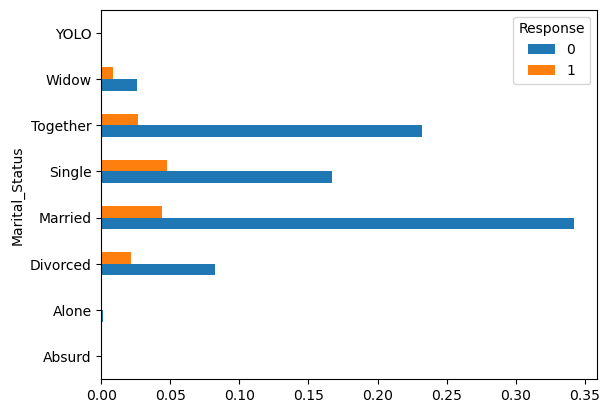

In [28]:
ct = pd.crosstab(df['Marital_Status'], df['Response'], normalize=True).plot.barh(stacked=False)

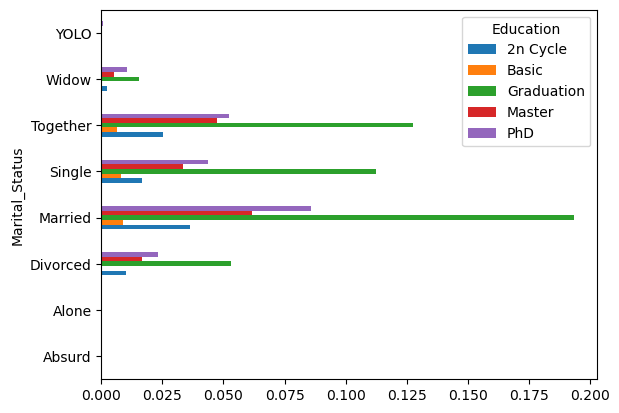

In [29]:
ct = pd.crosstab(df['Marital_Status'], df['Education'], normalize=True).plot.barh(stacked=False)

In [30]:
df.groupby(['Kidhome']).median(numeric_only=True).T

Kidhome,0,1,2
Year_Birth,1965.0,1973.0,1968.0
Income,63915.0,36975.0,36326.5
Teenhome,1.0,0.0,1.0
Recency,50.0,49.0,56.0
MntWines,398.0,25.0,26.0
MntFruits,22.0,3.0,1.0
MntMeatProducts,161.0,18.0,13.0
MntFishProducts,32.0,4.0,3.0
MntSweetProducts,22.0,3.0,1.0
MntGoldProds,39.0,12.0,8.5


# Balanceo de clases

In [31]:
categ_columns = ['Marital_Status','Education','Response']
for column in categ_columns:
    print('\n'+ column)
    print(df[column].value_counts())


Marital_Status
Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

Education
Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

Response
Response
0    1906
1     334
Name: count, dtype: int64


In [32]:
df['Marital_Status'].replace({'Widow':'Other','Alone':'Other','Absurd':'Other','YOLO':'Other'},inplace=True)

/var/folders/gb/nv8xcn1n2fj8nvh2rrjytk0r0000gn/T/ipykernel_15339/4217851425.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Marital_Status'].replace({'Widow':'Other','Alone':'Other','Absurd':'Other','YOLO':'Other'},inplace=True)


In [33]:
categ_columns = ['Marital_Status']
for column in categ_columns:
    print('\n' + column)
    print(df[column].value_counts())


Marital_Status
Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Other        84
Name: count, dtype: int64


In [34]:
df.groupby(['Marital_Status']).median(numeric_only=True).T

Marital_Status,Divorced,Married,Other,Single,Together
Year_Birth,1968.0,1971.000000,1958.0,1972.0,1969.0
Income,52683.0,52247.251354,55453.5,49277.5,52137.0
Kidhome,0.0,0.000000,0.0,0.0,0.0
Teenhome,1.0,0.000000,1.0,0.0,1.0
Recency,51.0,48.000000,48.0,51.0,51.0
MntWines,182.5,173.000000,327.0,153.5,183.5
MntFruits,7.5,7.000000,10.0,9.0,8.0
MntMeatProducts,71.5,64.000000,83.0,65.0,68.0
MntFishProducts,10.0,12.000000,21.5,12.0,12.0
MntSweetProducts,7.0,8.000000,10.5,9.0,9.0


In [35]:
df.shape

(2240, 26)

# Preparación antes del Split

In [36]:
df2 = df.copy()

In [37]:
df2.drop('Dt_Customer',axis=1,inplace=True)

In [38]:
print(df['Education'].unique())
print(df['Marital_Status'].unique())

df['Education'] = df['Education'].astype('category')
df['Marital_Status'] = df['Marital_Status'].astype('category')

['Graduation' 'PhD' 'Master' 'Basic' '2n Cycle']
['Single' 'Together' 'Married' 'Divorced' 'Other']


In [39]:
df2['MntWines-log'] = np.log(df2['MntWines']+1)
df2['MntFruits-log'] = np.log(df2['MntFruits']+1)
df2['MntMeatProducts-log'] = np.log(df2['MntMeatProducts']+1)
df2['MntFishProducts-log'] = np.log(df2['MntFishProducts']+1)
df2['MntSweetProducts-log'] = np.log(df2['MntSweetProducts']+1)
df2['NumDealsPurchases-log'] = np.log(df2['NumDealsPurchases']+1)
df2['NumWebPurchases-log'] = np.log(df2['NumWebPurchases']+1)
df2['NumCatalogPurchases-log'] = np.log(df2['NumCatalogPurchases']+1)


In [40]:
print(df2['Marital_Status'].value_counts())

df2['Marital_Status'] = df['Marital_Status'].replace({'Widow':'Other','Absurd':'Other','YOLO':'Other','Alone':'Other'},regex=True)
df2['Marital_Status'].value_counts()


Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Other        84
Name: count, dtype: int64


Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Other        84
Name: count, dtype: int64

In [41]:
df2.sample(4)

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,...,Complain,Response,MntWines-log,MntFruits-log,MntMeatProducts-log,MntFishProducts-log,MntSweetProducts-log,NumDealsPurchases-log,NumWebPurchases-log,NumCatalogPurchases-log
780,1974,PhD,Single,71466.0,0,0,86,412,12,546,...,0,0,6.023448,2.564949,6.304449,4.369448,5.209486,0.693147,1.609438,1.609438
959,1957,PhD,Divorced,54237.0,0,1,48,267,3,30,...,0,0,5.590987,1.386294,3.433987,1.609438,0.000000,1.609438,1.791759,1.098612
1972,1971,Graduation,Together,34600.0,1,1,8,199,33,60,...,0,1,5.298317,3.526361,4.110874,2.197225,1.386294,1.791759,1.791759,1.098612
555,1952,Graduation,Together,43462.0,1,1,50,90,17,97,...,0,0,4.510860,2.890372,4.584967,2.772589,1.945910,1.945910,1.609438,0.693147


In [42]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df2['Income_scale'] = StandardScaler().fit_transform(df2[['Income']])

In [43]:
print(df2.columns)

cols_num = ['Year_Birth', 'Income', 'Kidhome',
       'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3',
       'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2',
       'Complain', 'Response', 'MntWines-log', 'MntFruits-log',
       'MntMeatProducts-log', 'MntFishProducts-log', 'MntSweetProducts-log',
       'NumDealsPurchases-log', 'NumWebPurchases-log',
       'NumCatalogPurchases-log', 'Income_scale']

Index(['Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3',
       'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2',
       'Complain', 'Response', 'MntWines-log', 'MntFruits-log',
       'MntMeatProducts-log', 'MntFishProducts-log', 'MntSweetProducts-log',
       'NumDealsPurchases-log', 'NumWebPurchases-log',
       'NumCatalogPurchases-log', 'Income_scale'],
      dtype='object')


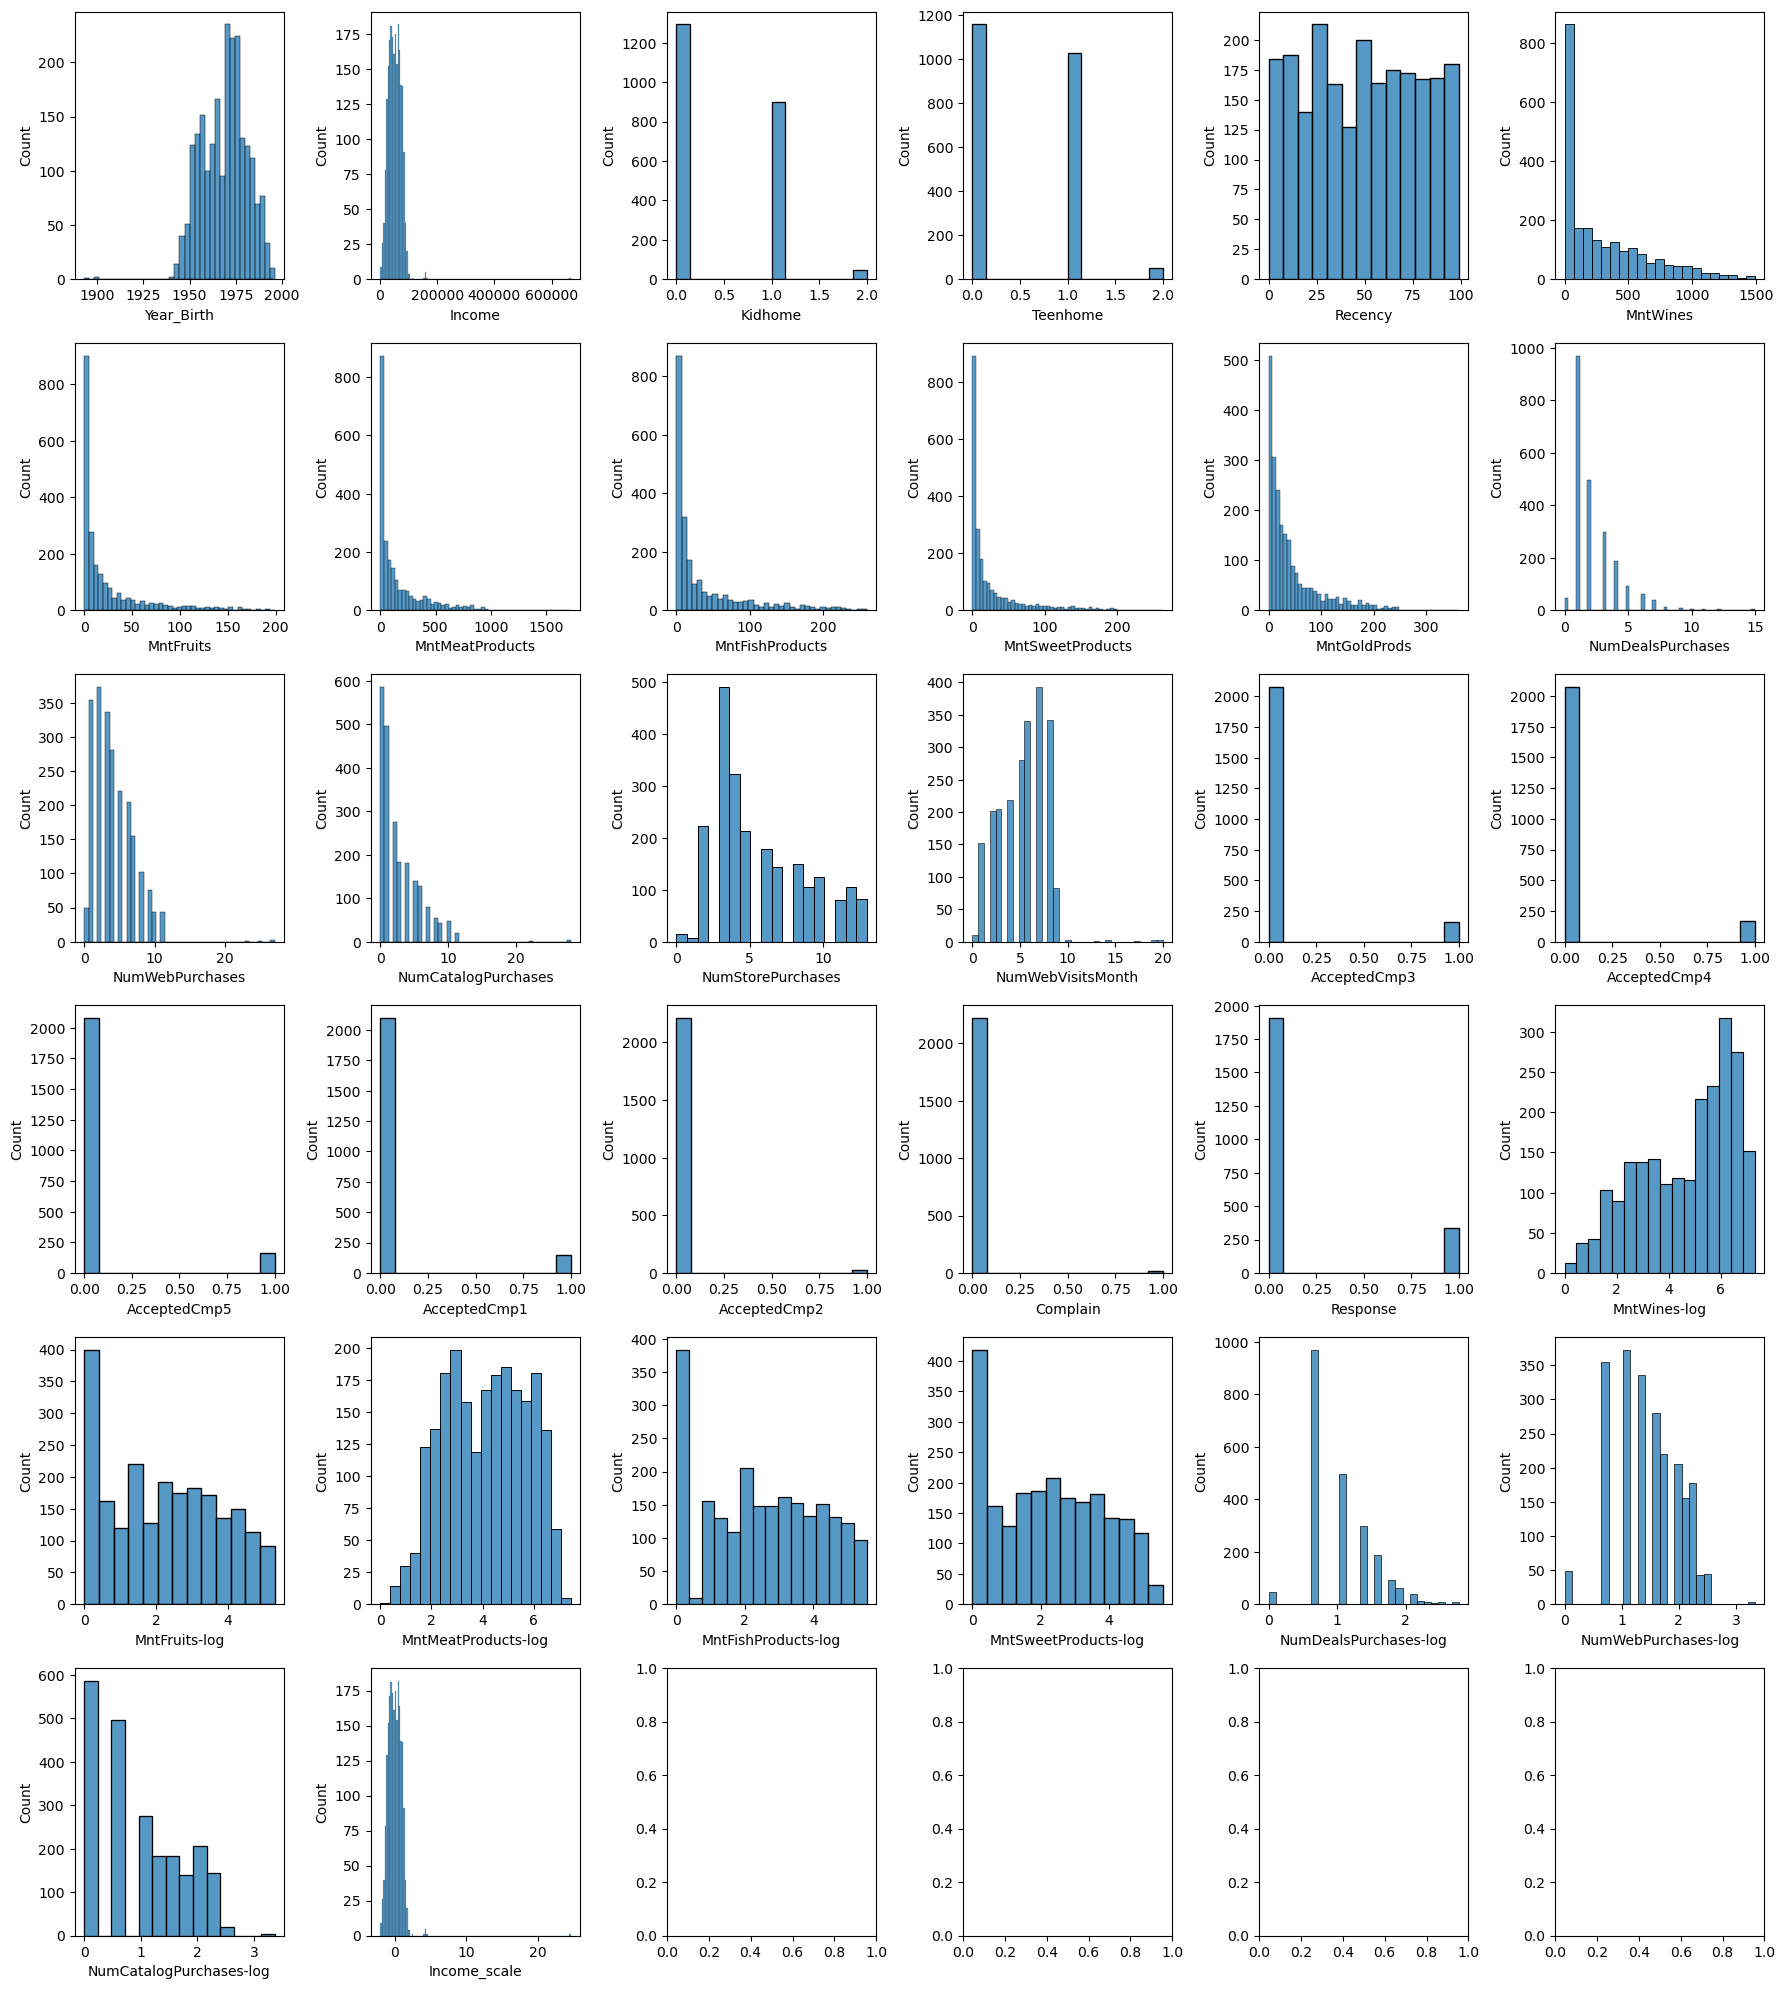

In [44]:
fig, axes = plt.subplots(nrows=6, ncols=6, figsize=(18,20))

for i, column in enumerate(cols_num):
    sns.histplot(df2[column], ax=axes[i//6, i%6], kde=False)

plt.tight_layout()
plt.show()

# Data split

In [45]:
from sklearn.model_selection import train_test_split

X = df2.drop('Response', axis=1)
y = df2['Response']

X = pd.get_dummies(X, drop_first=True, dtype=int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=1
)

In [46]:
X_train.head(3)

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,NumCatalogPurchases-log,Income_scale,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Married,Marital_Status_Other,Marital_Status_Single,Marital_Status_Together
1747,1946,66835.0,0,0,21,620,26,195,34,17,...,1.609438,0.582759,0,0,1,0,1,0,0,0
115,1962,50785.0,1,1,27,64,1,21,0,1,...,0.693147,-0.058415,0,1,0,0,0,0,1,0
1739,1971,42403.0,1,0,18,22,1,11,0,5,...,0.000000,-0.393263,0,0,0,1,1,0,0,0


In [47]:
print("{0:0.2f}% data is in training set".format((len(X_train)/len(df2.index))*100))
print("{0:0.2f}% data is in test set".format((len(X_test)/len(df2.index))*100))

70.00% data is in training set
30.00% data is in test set


In [48]:
print("Original Personal Loan True Values : {0} ({1:02}%)".format(len(df2.loc[df2['Response']==1]),(len(df2.loc[df2['Response']==1])/len(df2.index))*100))
print("Original Personal Loan False Values : {0} ({1:02}%)".format(len(df2.loc[df2['Response']==0]),(len(df2.loc[df2['Response']==0])/len(df2.index))*100))
print("")
print("Training Personal Loan True Values : {0} ({1:02}%)".format(len(y_train.loc[y_train[:]==1]),(len(y_train.loc[y_train[:]==1])/len(y_train))*100))
print("Training Personal Loan False Values : {0} ({1:02}%)".format(len(y_train.loc[y_train[:]==0]),(len(y_train.loc[y_train[:]==0])/len(y_train))*100))
print("")
print("Test Personal Loan True Values : {0} ({1:02}%)".format(len(y_test.loc[y_test[:]==1]),(len(y_test.loc[y_test[:]==1])/len(y_test))*100))
print("Test Personal Loan False Values : {0} ({1:02}%)".format(len(y_test.loc[y_test[:]==0]),(len(y_test.loc[y_test[:]==0])/len(y_test))*100))


Original Personal Loan True Values : 334 (14.910714285714285%)
Original Personal Loan False Values : 1906 (85.08928571428571%)

Training Personal Loan True Values : 226 (14.41326530612245%)
Training Personal Loan False Values : 1342 (85.58673469387756%)

Test Personal Loan True Values : 108 (16.071428571428573%)
Test Personal Loan False Values : 564 (83.92857142857143%)


# Prueba Simple con Regresión Logística

In [49]:
from sklearn import metrics 
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight={0:0.15,1:0.85},solver='liblinear')
model.fit(X_train, y_train)

y_predict = model.predict(X_test)

In [50]:
y_predict[:100]

array([1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0])

In [51]:
z = X_test.copy()
z['Response real'] = y_test
z['Response predicción'] = y_predict
z[['Response real','Response predicción']].head(10)
 

,Response real,Response predicción
779,0,1
389,0,0
510,0,1
1553,0,0
1172,0,1
1204,0,0
2057,0,0
1960,0,0
615,0,0
761,0,0


In [52]:
coef_df = pd.DataFrame(model.coef_)
coef_df.columns = X.columns
coef_df['intercept'] = model.intercept_
coef_df.T

,0
Year_Birth,-0.001726
Income,0.000007
Kidhome,0.316539
Teenhome,-0.884853
Recency,-0.027476
MntWines,0.001449
MntFruits,0.000738
MntMeatProducts,-0.000188
MntFishProducts,-0.001827
MntSweetProducts,-0.000287


# Matriz de confusión

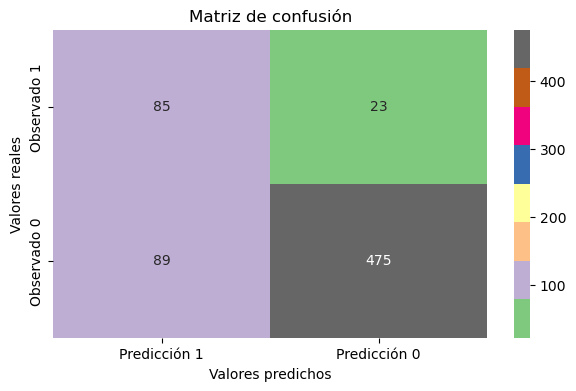

In [53]:
import matplotlib.pyplot as plt
from sklearn import metrics

cm = metrics.confusion_matrix(y_test, y_predict, labels=[1,0])

df_cm = pd.DataFrame(
    cm,
    index=['Observado 1', 'Observado 0'],
    columns=['Predicción 1', 'Predicción 0']
)

plt.figure(figsize=(7,4))

sns.heatmap(df_cm, annot=True, cmap='Accent', fmt='d')

plt.title('Matriz de confusión')
plt.ylabel('Valores reales')
plt.xlabel('Valores predichos')

plt.show()

In [54]:
df_cm

,Predicción 1,Predicción 0
Observado 1,85,23
Observado 0,89,475


In [55]:
TP = df_cm.iloc[0][0]
FP = df_cm.iloc[0][1]
FN = df_cm.iloc[1][0]
TN = df_cm.iloc[1][1]

print('TP=',TP,'FN=',FN,'FP=',FP,'TN=',TN)


TP= 85 FN= 89 FP= 23 TN= 475


/var/folders/gb/nv8xcn1n2fj8nvh2rrjytk0r0000gn/T/ipykernel_15339/2518295390.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  TP = df_cm.iloc[0][0]
/var/folders/gb/nv8xcn1n2fj8nvh2rrjytk0r0000gn/T/ipykernel_15339/2518295390.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  FP = df_cm.iloc[0][1]
/var/folders/gb/nv8xcn1n2fj8nvh2rrjytk0r0000gn/T/ipykernel_15339/2518295390.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  FN = df_

In [56]:
from sklearn.metrics import accuracy_score,f1_score,precision_score,recall_score,roc_auc_score,classification_report,confusion_matrix

y_pred = model.predict(X_test)
model_score =accuracy_score(y_test,y_pred)
recall_score = recall_score(y_test,y_pred)
precision_score = precision_score(y_test,y_pred)
f1_score = f1_score(y_test,y_pred)

print('Medidas del modelo')
print('-------------------------------------')
print('Accuracy = {0:0.2f}'.format(model_score))
print('Precision = {0:0.2f}'.format(precision_score))
print('Recall = {0:0.2f}'.format(recall_score))
print('f1_score = {0:0.2f}'.format(f1_score))
print('Roc Auc Score = {0:0.2f}')

Medidas del modelo
-------------------------------------
Accuracy = 0.83
Precision = 0.49
Recall = 0.79
f1_score = 0.60
Roc Auc Score = {0:0.2f}
